In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch

import os
import scanpy as sc

import seaborn as sns
import snapatac2 as snap

snap.__version__


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.9.0'

In [28]:

scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
atac_scanpy_color_map = dict(zip(scanpy_cluster + ['debrisOdoublets'], scanpy_colors + ['#000000']))
rna_scanpy_color_map = dict(zip(scanpy_cluster + ['no_rna_info'], scanpy_colors + ['#000000']))

## Load Data

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_stringent_calling.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['index'] = union_cell_info.index.map(lambda x: x + '-1')

union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,index
atac_bc,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,0.965116,True,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,0.990949,True,AAACAAGCATTTCTTC-1


In [3]:
nucleosome_info_file = os.path.join(Union_cell_subdir, 'nucleosome_signal_by_cell.csv')
nucleosome_info = pd.read_csv(nucleosome_info_file, index_col=0)
nucleosome_info['index'] = nucleosome_info.index.map(lambda x: x + '-1')
nucleosome_info.head(2)

,nucleosome_signal,index
atac_bc,,
AAACAAGCAAGTTAGT,-1.552972,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,-1.926050,AAACAAGCATTTCTTC-1


In [4]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)

,barcodes,atac_bc
0,AAAGCCTAGGATTATG-1,AAAGCCTAGGATTATG
1,AAAGGCGCACTAATCC-1,AAAGGCGCACTAATCC


In [5]:
data_filter = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered.h5ad'))

In [6]:
data = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))

data.obs['filtered_leiden'] = data.obs.index.map(data_filter.obs['filtered_leiden']).fillna('debrisOdoublets')
data.obs['amulet_doublet_atac'] = data.obs.index.isin(doublet_atac_barcodes['barcodes'])

data.obs['debris_doublets_flag'] = data.obs.apply(lambda row: 
    'debrisNdoublet' if row['DNA_debris'] == 'YES' and row['amulet_doublet_atac'] == True \
        else ('doublets' if row['amulet_doublet_atac'] == True \
            else ('Debris' if row['DNA_debris'] == 'YES' else 'clean')), axis=1)

# create a column by training '-1' of index and use it to map the 'rna_barcodes' column in union_cell_info
data.obs['atac_bc'] = data.obs.index.map(lambda x: x.split('-')[0])
data.obs['rna_barcodes'] = data.obs['atac_bc'].map(union_cell_info['rna_barcodes'])


# Vis

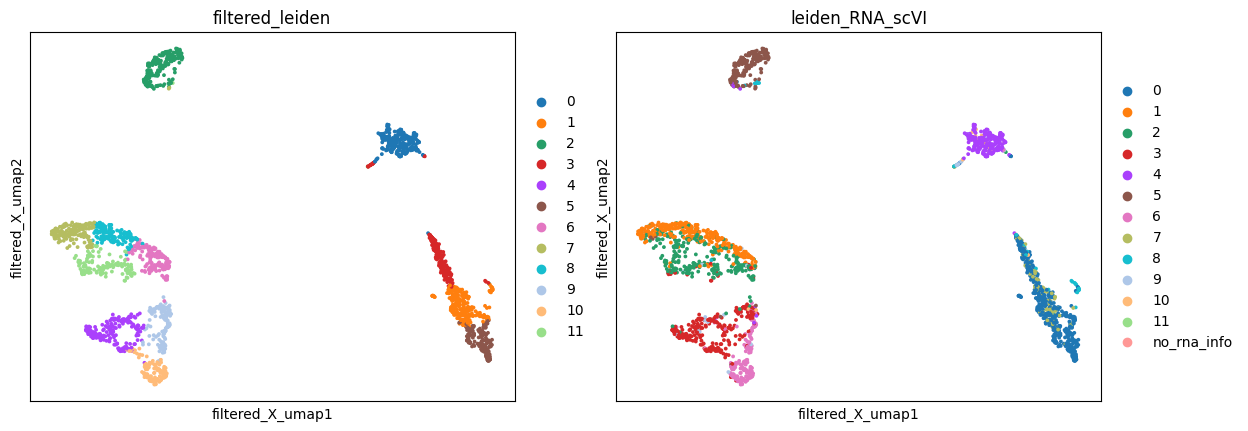

In [10]:
sc.pl.embedding(data_filter, basis='filtered_X_umap', color=['filtered_leiden',  'leiden_RNA_scVI', ], s=30, ncols=2, wspace=0.1)

# --

In [12]:
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')
h5_rna_union = sc.read_h5ad(h5_rna_union_file)
h5_rna_union

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2381 × 36601
    obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
    var: 'gene_ids', 'feature_types', 'genome'

In [13]:
rna_col_list = ['total_RNA_UMI', 'n_genes_by_RNA_counts', 'N_MT_counts']
for col in rna_col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs[col].fillna(0)

for col in rna_col_list:
    data.obs[col] = data.obs['rna_barcodes'].map(h5_rna_union.obs.set_index('rna_barcodes')[col]).fillna(np.nan)

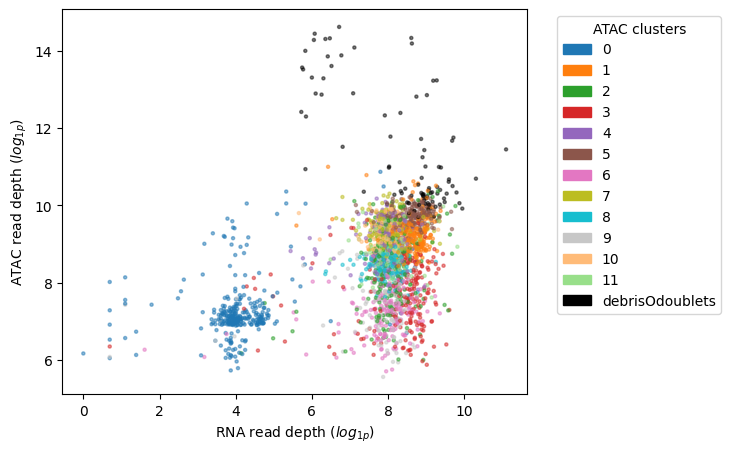

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
_ = ax.scatter(np.log1p(data.obs['total_RNA_UMI']), np.log1p(data.obs['n_fragment']), 
               c=data.obs['filtered_leiden'].map(scanpy_color_map),
               s=5, alpha=0.5)
ax.set_xlabel('RNA read depth ($log_{1p}$)')
ax.set_ylabel('ATAC read depth ($log_{1p}$)')
handles=[Patch(color=scanpy_color_map[cluster], label=cluster) for cluster in scanpy_cluster + ['debrisOdoublets']]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title='ATAC clusters')

/tmp/ipykernel_239022/3779092905.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correlation_mat = data.obs.groupby([ 'filtered_leiden',  'leiden_RNA_scVI']).size().unstack(fill_value=0)


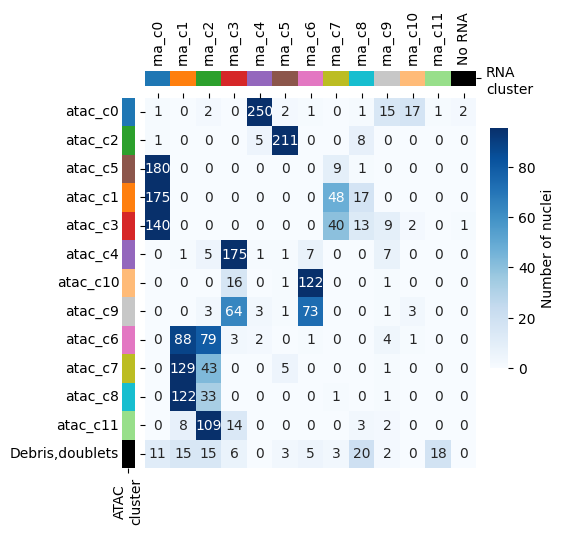

In [114]:
correlation_mat = data.obs.groupby([ 'filtered_leiden',  'leiden_RNA_scVI']).size().unstack(fill_value=0)
correlation_mat.index.name = None
correlation_mat.columns.name = None
correlation_mat_index = correlation_mat.index.astype(str)
correlation_mat_columns = correlation_mat.columns.astype(str)


col_colors = pd.DataFrame({
    'RNA\ncluster': correlation_mat.columns.map(rna_scanpy_color_map),
}, index= correlation_mat_columns)
row_colors = pd.DataFrame({
    'ATAC\ncluster': correlation_mat.index.map(atac_scanpy_color_map),
}, index=correlation_mat_index)

# Rename 
correlation_mat.columns = ["No RNA" if i == "no_rna_info" else f"rna_c{i}" for i in correlation_mat_columns]
correlation_mat.index = ["Debris,doublets" if i == "debrisOdoublets" else f"atac_c{i}" for i in correlation_mat_index]
col_colors.index = ["No RNA" if i == "no_rna_info" else f"rna_c{i}" for i in correlation_mat_columns]
row_colors.index = ["Debris,doublets" if i == "debrisOdoublets" else f"atac_c{i}" for i in correlation_mat_index]

c_sd = correlation_mat.values.std()
c_mean = correlation_mat.values.mean()
c_min = np.max((c_mean - 2*c_sd, 0))
c_max = c_mean + 2*c_sd
c_center = 0.5 * (c_min + c_max)

g = sns.clustermap(correlation_mat, col_colors=col_colors, row_colors=row_colors, 
                   col_cluster=False, 
                   cmap='Blues', annot=True, fmt='d', xticklabels=True, yticklabels=True,
                   cbar_pos=(0.8, 0.3, 0.03, 0.4), 
                cbar_kws={'label': 'Number of nuclei'}, 
                vmin = c_min, vmax = c_max,
                center = c_center,
                figsize=(6, 6))
g.ax_row_dendrogram.set_visible(False) # Hide Row tree
g.ax_col_dendrogram.set_visible(False) # Hide Column tree



g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.yaxis.set_label_position("left")

g.ax_heatmap.xaxis.tick_top()
g.ax_heatmap.xaxis.set_label_position("top")

g.ax_heatmap.tick_params(axis='y', pad=15)
g.ax_heatmap.tick_params(axis='x', pad=20, rotation=90)
#_ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='center')


In [117]:
data.obs['filtered_leiden'].value_counts()

filtered_leiden
0                  292
1                  240
2                  225
3                  205
4                  197
5                  190
7                  178
6                  178
8                  157
9                  148
10                 140
11                 136
debrisOdoublets     98
Name: count, dtype: int64

In [119]:
2384 - 98 

2286

In [118]:
data

AnnData object with n_obs × n_vars = 2384 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden', 'debris_doublets_flag', 'atac_bc', 'rna_barcodes', 'total_RNA_UMI', 'n_genes_by_RNA_counts', 'N_MT_counts'
    var: 'count', 'selected'
    uns: 'DNA_debris_colors', 'TSS_profile', '_3set_identified_by_atac_colors', 'amulet_doublet_atac_colors', 'frac_overlap_TSS', 'leiden_RNA_scVI_colors', 'leiden_colors', 'leiden_scanpy', 'leiden_scanpy_colors', 'library_tsse', 'reference_sequences', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap', 'fragment_paired'
    obsp: 'distances'

In [116]:
250 / (data.obs['leiden_RNA_scVI'] == '4').sum(), 15 / (data.obs['leiden_RNA_scVI'] == '9').sum(), 17 / (data.obs['leiden_RNA_scVI'] == '10').sum()

(np.float64(0.9578544061302682),
 np.float64(0.3488372093023256),
 np.float64(0.7391304347826086))

In [24]:
data.obs.head(2)

,n_fragment,frac_dup,frac_mito,rna_pass_CR,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,_3set_identified_by_atac,...,tsse,leiden,leiden_scanpy,filtered_leiden,debris_doublets_flag,atac_bc,rna_barcodes,total_RNA_UMI,n_genes_by_RNA_counts,N_MT_counts
AAACAAGCAAGTTAGT-1,2412,0.592705,0.0,True,True,True,True,both,both,common,...,37.408568,7,7,9,clean,AAACAAGCAAGTTAGT,GGCTAGTGTGTTAGCA,2035.0,1147.0,267.0
AAACAAGCATTTCTTC-1,9027,0.590816,0.0,True,True,True,True,both,both,common,...,11.363636,0,3,0,clean,AAACAAGCATTTCTTC,GGCTAGTGTACGTTTC,3237.0,1531.0,847.0
